In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd

In [3]:
stw = 7077401291
stw2 = 7077404138

In [4]:
from pathlib import Path

from odin.level0.acfile import ACfile
from odin.level0.attfile import AttFile
from odin.level0.fbafile import FBAfile
from odin.level0.shkfile import SHKfile
from odin.level1.process import Level1

file = Path("./data/1a5d2ae7.ac1")
ac = ACfile(file).dataframe
att = AttFile(Path("./data/1a5c499d.att")).dataframe
shk = SHKfile(Path("./data/1a5d2ae9.shk")).dataframe
fba = FBAfile(Path("./data/1a5d2ae8.fba")).dataframe

Applying overflow correction


In [5]:
l1 = Level1(
    ac=ac,
    att=att,
    shk=shk,
    fba=fba,
)

(4608,) (4396,) (204,)
(4608, 8, 112) float64


/workspace/odin/src/odin/level1/intensity_calibration.py:50: RuntimeWarning: invalid value encountered in divide
  W = np.nanmedian(span, axis=-1, keepdims=True) / span
/workspace/odin/src/odin/level1/intensity_calibration.py:51: RuntimeWarning: All-NaN slice encountered
  W = W / np.nanmedian(W, axis=-1, keepdims=True)


## Sweeps identification

In [6]:
# sync = l1.shk["ACDC1 sync"].astype("uint16").to_numpy() >> 3 & 0xF
# print(sync[40:60])
# mask = np.where((sync == 5) |  (sync == 10) )
# stws = l1.ac.index[mask]
# stws

In [7]:
def stitch_full_band(x: np.ndarray, y: np.ndarray):
    """
    x, y: (n, 8, 112)
    returns: x_full, y_full: (n, 896) where x_full is monotonic increasing per row
    """
    assert x.shape == y.shape
    n = x.shape[0]

    X = x.reshape(n, -1)  # (n, 896)
    Y = y.reshape(n, -1)  # (n, 896)

    # If x can contain NaNs, push them to the end (optional)
    X_for_sort = np.where(np.isnan(X), np.inf, X)

    idx = np.argsort(X_for_sort, axis=1, kind="mergesort")  # stable sort
    rows = np.arange(n)[:, None]

    X_full = X[rows, idx]
    Y_full = Y[rows, idx]
    return X_full, Y_full

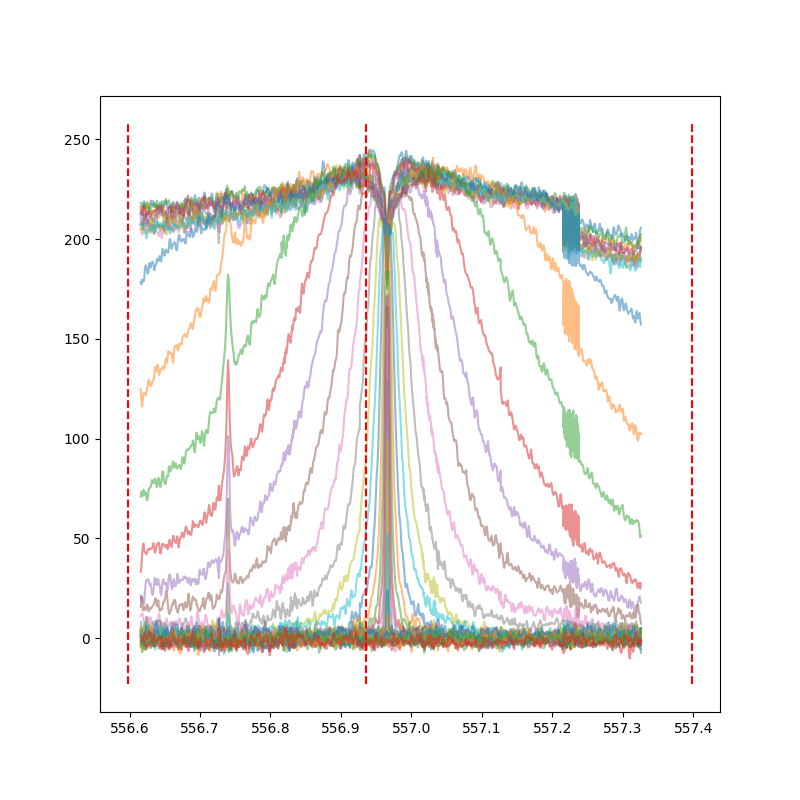

In [8]:
import matplotlib.pyplot as plt
plt.close("all")
stw1, stw2 = 7077176154, 7077178969
freq = np.stack(
    l1.frequency_grid["frequency_grid"].loc[stw1:stw2].to_numpy()
).astype(np.float64)
cal = np.stack(l1.calibrated["calibrated"].loc[stw1:stw2].to_numpy())


fig, ax = plt.subplots(figsize=(8, 8))
x, y = stitch_full_band(freq, cal)
ax.plot(
    x.T / 1e9,
    # l1.frequency_grid["frequency_grid"].iloc[1].reshape(-1, 112 * 8).T / 1e9,
    y.T,
    # ls="none",
    # marker=".",
    alpha=0.5,
)

if l1.ac.backend.iloc[0] == "AC1":
    ax.vlines(
            x=[556.936, 556.598, 557.398],
            ymin=ax.get_ylim()[0],
            ymax=ax.get_ylim()[1],
            colors="r",
            linestyles="--",
            label="H₂O 556.936 GHz",
        )
plt.show()

In [ ]:
import json

l1b = json.loads(Path("./data/l1b_spectrum.json").read_text())
LO_freq = np.array(l1b["Frequency"]["LOFreq"])
if_freq = np.array(l1b["Frequency"]["IFreqGrid"])
data = np.array(l1b["Spectrum"])

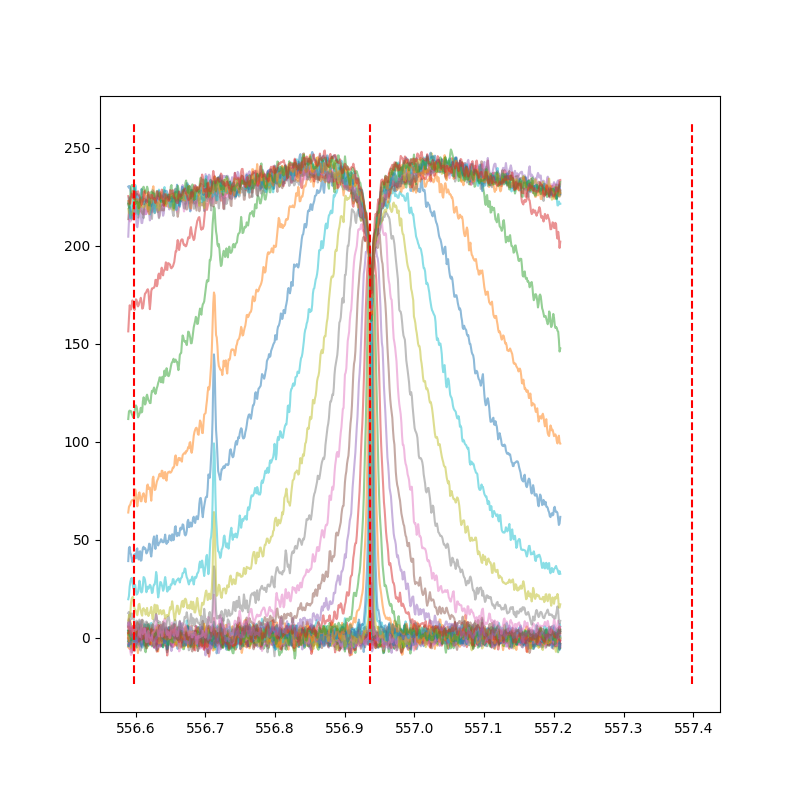

In [10]:
fig,ax = plt.subplots(figsize=(8, 8))
ax.plot(
    (LO_freq[:,None] + if_freq[None,:] ).T/1e9,
    data.T,
    alpha=0.5,)
ax.vlines(
        x=[556.936, 556.598, 557.398],
        ymin=ax.get_ylim()[0],
        ymax=ax.get_ylim()[1],
        colors="r",
        linestyles="--",
        label="H₂O 556.936 GHz",
    )
plt.show()